**Mahan Madani - 830504035**

Assignment 2 | Question 2: Image Compression with Autoencoder

## Table of Contents

- [Import libraries and Custom Classes](#import-libraries-and-custom-classes)
- [Load and Prepare Dataset](#load-and-prepare-dataset)
    - [Sample image](#sample-image)
- [Image to Vector Transformation](#image-to-vector-transformation)
- [Helper Functions](#helper-functions)
- [2.1 Hidden Layer Nuerons](#21-hidden-layer-neurons)
    - [4 Neurons](#4-neurons)
    - [16 Neurons](#16-neurons)
    - [32 Neurons](#32-neurons)
    - [Hidden Layer Comparison](#hidden-layer-comparison)
- [2.2 Block Size](#22-block-size)
    - [4*4 Blocks](#4--4-blocks)
    - [8*8 Blocks](#8--8-blocks)
    - [16*16 Blocks](#16--16-blocks)
    - [Block Size Comparison](#block-size-comparison)
- [2.3 Momentum](#23-momentum)
    - [Momentum 0.0](#momentum-00)
    - [Momentum 0.5](#momentum-05)
    - [Momentum Comparison](#momentum-comparison)

## Import Libraries and Custom Classes

In [5]:
import numpy as np
import struct
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import os
import math

In [2]:
from MLP import MLP, LinearLayer
from MLP import MSELoss, CrossEntropyLoss, WeightInitializer
from MLP import ReLU, LeakyReLU, Linear, Sigmoid, Tanh, Softmax
from MLP import shuffle_data, reset_seed, plot_metric_over_epoch, calculate_psnr, GLOBAL_SEED
from MLP import plot_train_metrics

## Load and Prepare Dataset

Download the Fashion_MNIST dataset and extract the .gz files in the selected path.

In [92]:
IMAGE_DIM = 28
fashion_mnist_path = "Dataset/Fashion_MNIST"

In [93]:
# Retrieve Fashion MNIST Images and labels
def load_idx_images(filename):
    with open(filename, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        data = data.reshape(num, rows, cols)
    return normalize_pixels(data)

def load_idx_labels(filename):
    with open(filename, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


# Normalize and denormalize pixel values
def normalize_pixels(image):
    return image / 255.0

def denormalize_pixels(image):
    return (image * 255).astype(np.uint8)

In [94]:
train_images = load_idx_images(f"{fashion_mnist_path}/train-images-idx3-ubyte")
train_labels = load_idx_labels(f"{fashion_mnist_path}/train-labels-idx1-ubyte")

test_images = load_idx_images(f"{fashion_mnist_path}/t10k-images-idx3-ubyte")
test_labels = load_idx_labels(f"{fashion_mnist_path}/t10k-labels-idx1-ubyte")

In [95]:
# Display a numpy array as an image
def display_image(image, title=''):
    if image.shape is not (IMAGE_DIM, IMAGE_DIM):
        image = image.reshape(IMAGE_DIM, IMAGE_DIM)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
    
def display_and_compare_images(img_original, img_reconstructed):
    plt.figure(figsize=(7, 4))
    
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.imshow(img_original, cmap='gray')
    plt.title('Original Image')
    
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title('Reconstructed Image')
    
    plt.tight_layout()
    plt.show()

### One-hot encoding the labels

In [96]:
FASHION_MNIST_LABELS = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [97]:
def one_hot_encode(labels):
    encoder = OneHotEncoder(sparse_output=False)
    return encoder.fit_transform(labels.reshape(-1, 1))

def one_hot_to_label(one_hot_vec, label_dict=FASHION_MNIST_LABELS):
    index = int(np.argmax(one_hot_vec))
    return label_dict[index]

In [98]:
X_train = train_images.reshape(len(train_images), -1)
X_test = test_images.reshape(len(test_images), -1)

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

In [99]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


### Sample image:

Sneaker


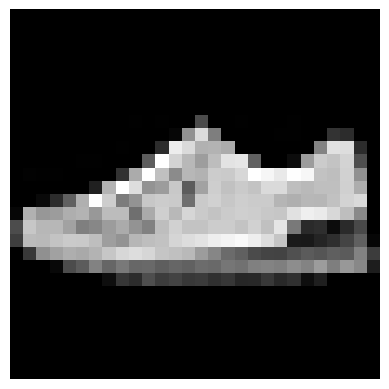

In [100]:
img = X_train[126]
print(one_hot_to_label(y_train[126]))
display_image(img)

## Create Train-Validation Set

In [101]:
def train_val_split(X, y, val_ratio, shuffle=True, seed=GLOBAL_SEED):
    N = len(X)
    indices = np.arange(N)

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(indices)

    val_size = int(N * val_ratio)

    val_idx = indices[:val_size]
    train_idx = indices[val_size:]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


In [102]:
VAL_RATIO = 0.2
X_train, y_train, X_val, Y_val = train_val_split(X_train, y_train, VAL_RATIO)

In [103]:
print(X_train.shape)
print(X_val.shape)

(48000, 784)
(12000, 784)


In [104]:
INPUT_SIZE = X_train.shape[1]
VALIDATION_IDX = 666  # used to display one image from the validation set and its reconstruction

## Helper Functions

In [54]:
def test_with_PSNR(reconstructed_images, target_images, val_idx):    
    psnr_sum = 0
    for target_image, reconstructed_image in zip(target_images, reconstructed_images):
        psnr_sum += calculate_psnr(target_image, reconstructed_image)
    psnr_mean = psnr_sum / len(target_images)
    print(f"Mean PSNR: {psnr_mean:8f}\n")
    
    # Display and compare one image and its respective reconstruction
    target_image = target_images[val_idx]
    reconstructed_image = reconstructed_images[val_idx]

    print(f"Sample image", end=' - ')
    print(f"PSNR: {calculate_psnr(target_image, reconstructed_image):6f}" )
    display_and_compare_images(img_original=target_image, img_reconstructed=reconstructed_image)
    
    return float(psnr_mean)

In [55]:
def get_model_predictions(model, vectorized_images):
    predictions = []
    for vector in vectorized_images:
        predictions.append(model.forward(vector))
    return np.array(predictions)

In [58]:
def train_autoencoder_model(model, X_train, X_val, epochs=50, batch_size=1):    
    # Train Autoencoder Model
    model.train(X_train, X_train, batch_size=batch_size,
                epochs=epochs, print_interval=math.ceil(epochs/10), 
                test_model=True, X_test=X_val, Y_test=X_val)

In [81]:
def evaluate_autoencoder_model(model, X_val):
    # Plot model's loss history
    print("Loss history over epochs:")
    plot_metric_over_epoch(model.train_loss_list, model.test_loss_list, val=True, title="Mean Loss over Epochs", figure_size=(6,4))
    
    # Reconstruct validation images from model prediction 
    val_predictions = get_model_predictions(model, X_val)
    val_predictions = val_predictions.reshape(-1, IMAGE_DIM, IMAGE_DIM)
    X_val = X_val.reshape(-1, IMAGE_DIM, IMAGE_DIM)
    
    # Evaluate image reconstructione by comparing them to the original image using the PSNR metric
    print("\nValidation data", end=' - ')
    val_psnr = test_with_PSNR(reconstructed_images=val_predictions, target_images=X_val, val_idx=VALIDATION_IDX)
    
    return val_psnr

In [ ]:
# def plot_metric_over_epoch(train_metric_list, test_metric_list=None, val=False, title="", y_label="Mean Loss", figure_size=(8, 5)):
#     plt.figure(figsize=figure_size)

#     epochs = np.arange(1, len(train_metric_list) + 1)
#     plt.plot(epochs, train_metric_list, label='Train', linewidth=2)
#     if test_metric_list is not None:
#         label = 'Validation' if val else 'Test' 
#         plt.plot(epochs, test_metric_list, color='salmon', label=label, linewidth=2)

#     plt.xlabel('Epoch')
#     plt.ylabel(y_label)
#     plt.title(title)
#     plt.grid(True, linestyle="--", alpha=0.4)
#     plt.legend()
#     # plt.tight_layout()
#     plt.show()

## 3.1 Train Autoencoder

### 3.1.a Hidden Layer Neurons

In [66]:
lr = 0.001
epochs = 10
batch_size = 1

Model 1: Hidden layer size = 64

In [67]:
hidden_layer_size = 64

model_1 = MLP(
    layer_sizes=[INPUT_SIZE, hidden_layer_size, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_1)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 64),   Activation: Sigmoid
  Layer  2: Linear Block (64, 784),   Activation: Sigmoid
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [68]:
train_autoencoder_model(model_1, X_train, X_val, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.056627,   Test Loss: 0.039574
Epoch    2 /   10,   Train Loss: 0.033158,   Test Loss: 0.029451
Epoch    3 /   10,   Train Loss: 0.027178,   Test Loss: 0.025696
Epoch    4 /   10,   Train Loss: 0.024377,   Test Loss: 0.023547
Epoch    5 /   10,   Train Loss: 0.022661,   Test Loss: 0.022144
Epoch    6 /   10,   Train Loss: 0.021462,   Test Loss: 0.021099
Epoch    7 /   10,   Train Loss: 0.020518,   Test Loss: 0.020236
Epoch    8 /   10,   Train Loss: 0.019716,   Test Loss: 0.019489
Epoch    9 /   10,   Train Loss: 0.019012,   Test Loss: 0.018829
Epoch   10 /   10,   Train Loss: 0.018390,   Test Loss: 0.018247


Loss history over epochs:


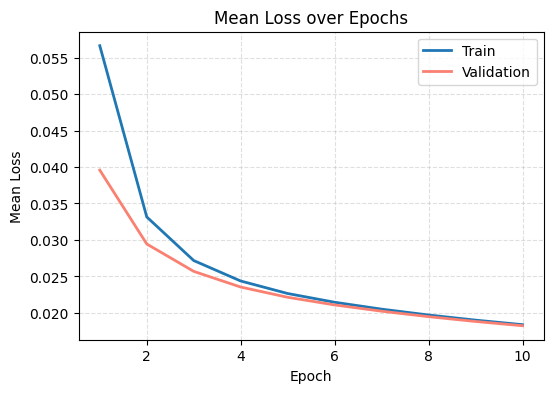


Validation data - Mean PSNR: 17.937485

Sample image - PSNR: 17.266588


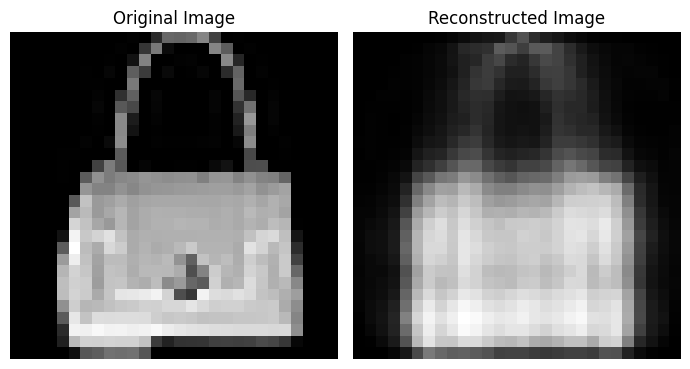

In [83]:
psnr_1 = evaluate_autoencoder_model(model_1, X_val)

Model 2: Hidden layer size = 128

In [76]:
hidden_layer_size = 128

model_2 = MLP(
    layer_sizes=[INPUT_SIZE, hidden_layer_size, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_2)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: Sigmoid
  Layer  2: Linear Block (128, 784),   Activation: Sigmoid
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [77]:
train_autoencoder_model(model_2, X_train, X_val, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.045405,   Test Loss: 0.030558
Epoch    2 /   10,   Train Loss: 0.026670,   Test Loss: 0.024273
Epoch    3 /   10,   Train Loss: 0.022554,   Test Loss: 0.021385
Epoch    4 /   10,   Train Loss: 0.020281,   Test Loss: 0.019523
Epoch    5 /   10,   Train Loss: 0.018666,   Test Loss: 0.018087
Epoch    6 /   10,   Train Loss: 0.017381,   Test Loss: 0.016933
Epoch    7 /   10,   Train Loss: 0.016343,   Test Loss: 0.016000
Epoch    8 /   10,   Train Loss: 0.015495,   Test Loss: 0.015229
Epoch    9 /   10,   Train Loss: 0.014785,   Test Loss: 0.014577
Epoch   10 /   10,   Train Loss: 0.014180,   Test Loss: 0.014017


Loss history over epochs:


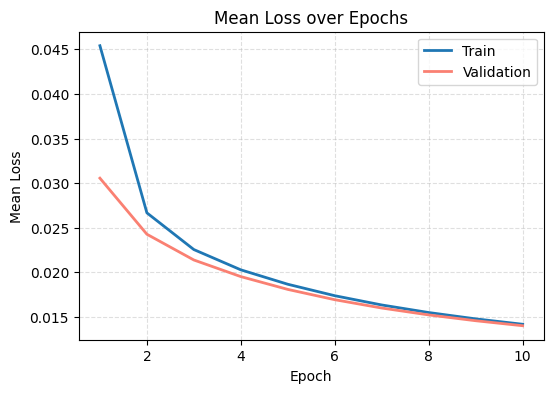


Validation data - Mean PSNR: 19.178415

Sample image - PSNR: 18.128597


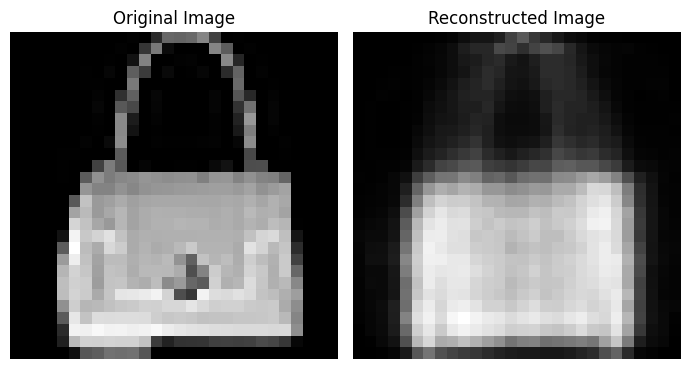

In [84]:
psnr_2 = evaluate_autoencoder_model(model_2, X_val)

### 3.1.b Model Architecture

Model 3: Architecture  768 - 256 - 64 - 256 - 768

In [85]:
model_3 = MLP(
    layer_sizes=[INPUT_SIZE, 256, 64, 256, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_3)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 256),   Activation: Sigmoid
  Layer  2: Linear Block (256, 64),   Activation: Sigmoid
  Layer  3: Linear Block (64, 256),   Activation: Sigmoid
  Layer  4: Linear Block (256, 784),   Activation: Sigmoid
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [86]:
train_autoencoder_model(model_3, X_train, X_val, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

KeyboardInterrupt: 

In [ ]:
psnr_3 = evaluate_autoencoder_model(model_3, X_val)

Model 4: Architecture  768 - 256 - 128 - 64 - 128 - 256 - 768

In [ ]:
model_4 = MLP(
    layer_sizes=[INPUT_SIZE, 256, 128, 64, 128, 256, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_4)

In [ ]:
train_autoencoder_model(model_4, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_4 = evaluate_autoencoder_model(model_4, X_val)

In [232]:
h16_train_images_reconstructed, h16_test_images_reconstructed = train_model(h16_model, train_images, test_images, n, epochs, batch_size)

Convert image dataset to vectorized blocks:

91 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 93184.

5 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 5120.



Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.010676,   Test Loss: 0.006356
Epoch   10 /   50,   Train Loss: 0.007244,   Test Loss: 0.003751
Epoch   15 /   50,   Train Loss: 0.006090,   Test Loss: 0.002941
Epoch   20 /   50,   Train Loss: 0.005577,   Test Loss: 0.002579
Epoch   25 /   50,   Train Loss: 0.005111,   Test Loss: 0.002242
Epoch   30 /   50,   Train Loss: 0.004671,   Test Loss: 0.001926
Epoch   35 /   50,   Train Loss: 0.004296,   Test Loss: 0.001662
Epoch   40 /   50,   Train Loss: 0.004007,   Test Loss: 0.001461
Epoch   45 /   50,   Train Loss: 0.003795,   Test Loss: 0.001319
Epoch   50 /   50,   Train Loss: 0.003638,   Test Loss: 0.001219

Reconstruct full images from the model's output vectors:

93184 Vectors of size 64 converted to 93184 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.

5120 Vectors of size 64 converted to 5120 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.



Loss history over epochs:


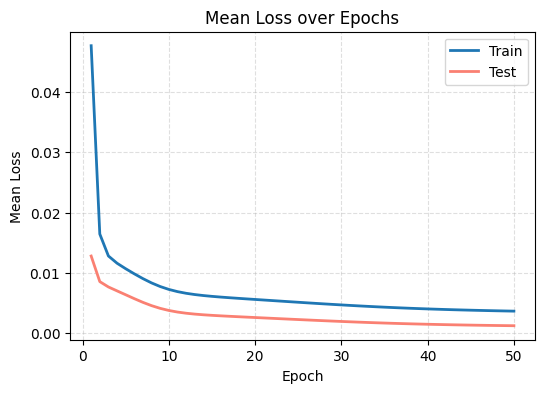


Train data - Mean PSNR: 27.502666

Sample image - PSNR: 18.076405


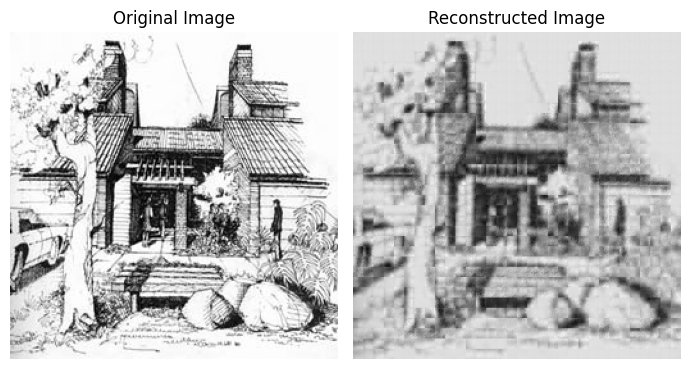


Test data - Mean PSNR: 30.412798

Sample image - PSNR: 31.606249


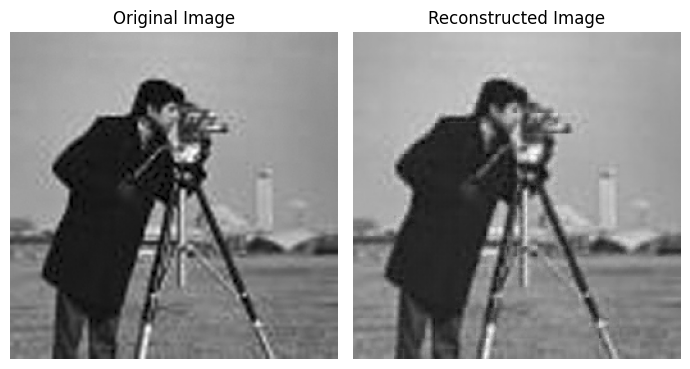

In [233]:
h16_psnr_train, h16_psnr_test = evaluate_model(h16_model, train_images, h16_train_images_reconstructed, test_images, h16_test_images_reconstructed)

### 32 Neurons

In [234]:
hidden_layer_size = 32

h32_model = MLP(
    layer_sizes=[n*n, hidden_layer_size, n*n],
    activations=[Sigmoid(), Linear()],
    loss="mse",
    lr=lr,
    momentum=momentum,
    weight_type="xavier"
)

print(h32_model)

Multi-Layer Perceptron Details:
Input Size: 64
Output Size: 64
Architecture:
  Layer  1: Linear Block (64, 32),   Activation: Sigmoid
  Layer  2: Linear Block (32, 64),   Activation: Linear
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [235]:
h32_train_images_reconstructed, h32_test_images_reconstructed = train_model(h32_model, train_images, test_images, n, epochs, batch_size)

Convert image dataset to vectorized blocks:

91 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 93184.

5 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 5120.



Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.009953,   Test Loss: 0.005658
Epoch   10 /   50,   Train Loss: 0.006522,   Test Loss: 0.003169
Epoch   15 /   50,   Train Loss: 0.005411,   Test Loss: 0.002440
Epoch   20 /   50,   Train Loss: 0.004752,   Test Loss: 0.001987
Epoch   25 /   50,   Train Loss: 0.004226,   Test Loss: 0.001625
Epoch   30 /   50,   Train Loss: 0.003845,   Test Loss: 0.001370
Epoch   35 /   50,   Train Loss: 0.003579,   Test Loss: 0.001201
Epoch   40 /   50,   Train Loss: 0.003383,   Test Loss: 0.001084
Epoch   45 /   50,   Train Loss: 0.003224,   Test Loss: 0.000993
Epoch   50 /   50,   Train Loss: 0.003085,   Test Loss: 0.000917

Reconstruct full images from the model's output vectors:

93184 Vectors of size 64 converted to 93184 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.

5120 Vectors of size 64 converted to 5120 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.



Loss history over epochs:


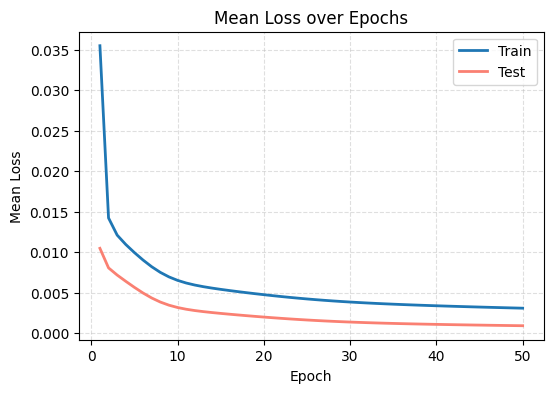


Train data - Mean PSNR: 28.482511

Sample image - PSNR: 18.595025


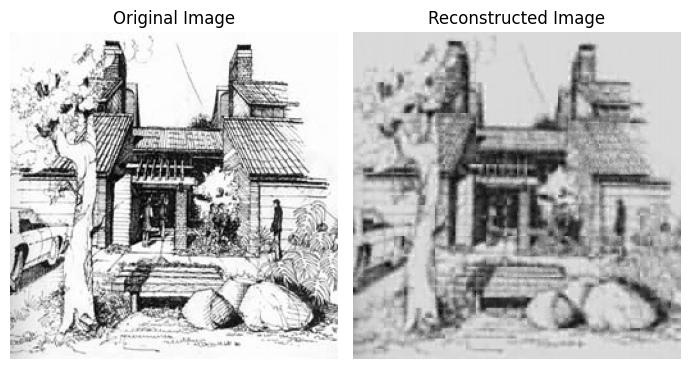


Test data - Mean PSNR: 31.664439

Sample image - PSNR: 33.001478


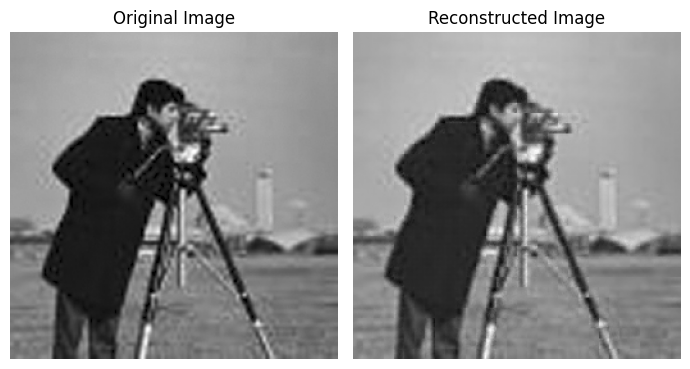

In [236]:
h32_psnr_train, h32_psnr_test = evaluate_model(h32_model, train_images, h32_train_images_reconstructed, test_images, h32_test_images_reconstructed)

### Hidden Layer Comparison

In [278]:
print( 'Model Evaluation Summary:\n\n' +
       '         Model        | Train Loss | Test Loss  | Train PSNR  | Test PSNR\n' +
       '----------------------------------------------------------------------------\n' +
      f'  Hidden Layers = 4   |  {h4_model.train_loss_list[-1]:6f}  |  {h4_model.test_loss_list[-1]:6f}  |  {h4_psnr_train:6f}  | {h4_psnr_test:6f}\n' +
      f'  Hidden Layers = 16  |  {h16_model.train_loss_list[-1]:6f}  |  {h16_model.test_loss_list[-1]:6f}  |  {h16_psnr_train:6f}  | {h16_psnr_test:6f}\n' +
      f'  Hidden Layers = 32  |  {h32_model.train_loss_list[-1]:6f}  |  {h32_model.test_loss_list[-1]:6f}  |  {h32_psnr_train:6f}  | {h32_psnr_test:6f}\n')

Model Evaluation Summary:

         Model        | Train Loss | Test Loss  | Train PSNR  | Test PSNR
----------------------------------------------------------------------------
  Hidden Layers = 4   |  0.006343  |  0.003172  |  23.979466  | 25.886967
  Hidden Layers = 16  |  0.003638  |  0.001219  |  27.502666  | 30.412798
  Hidden Layers = 32  |  0.003085  |  0.000917  |  28.482511  | 31.664439



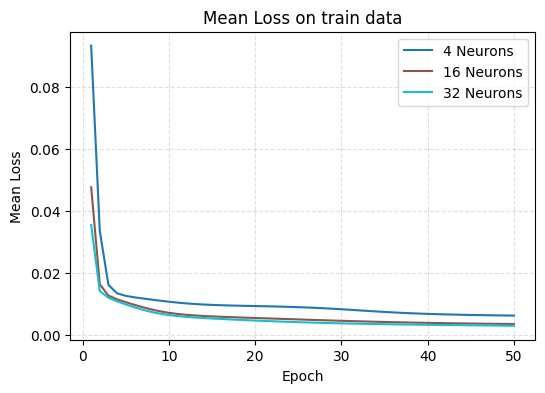

In [239]:
plot_train_metrics([h4_model.train_loss_list, h16_model.train_loss_list, h32_model.train_loss_list],
                    labels=['4 Neurons', '16 Neurons', '32 Neurons'],
                    title="Mean Loss on train data",
                    figure_size=(6, 4))

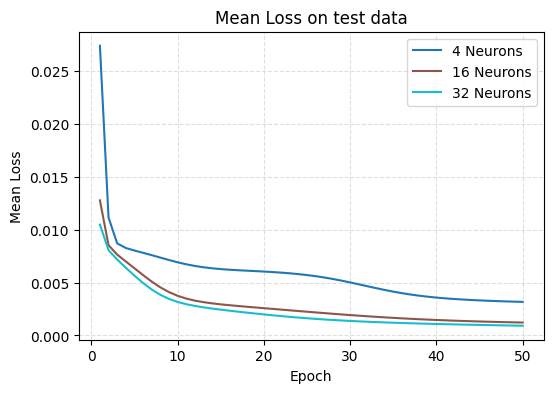

In [240]:
plot_train_metrics([h4_model.test_loss_list, h16_model.test_loss_list, h32_model.test_loss_list],
                    labels=['4 Neurons', '16 Neurons', '32 Neurons'],
                    title="Mean Loss on test data",
                    figure_size=(6, 4))

## 2.2 Block Size

In [148]:
# default values for for all models in this section. Only the block size (n) changes
momentum = 0.0
lr = 0.001
hidden_layer_size = 32
epochs = 50
batch_size = 16

### 4 * 4 Blocks

In [ ]:
n = 4

n4_model = MLP(
    layer_sizes=[n*n, hidden_layer_size, n*n],
    activations=[Sigmoid(), Linear()],
    loss="mse",
    lr=lr,
    momentum=momentum,
    weight_type="xavier"
)

print(n4_model)

Multi-Layer Perceptron Details:
Input Size: 16
Output Size: 16
Architecture:
  Layer  1: Linear Block (16, 32),   Activation: Sigmoid
  Layer  2: Linear Block (32, 16),   Activation: Linear
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [142]:
n4_train_images_reconstructed, n4_test_images_reconstructed = train_model(n4_model, train_images, test_images, n, epochs, batch_size)

Convert image dataset to vectorized blocks:

91 Images of size 256*256 divided to 4096 Blocks (shape 4*4) per image.
Each block transformed to a vector of size 16. Total Vectors: 372736.

5 Images of size 256*256 divided to 4096 Blocks (shape 4*4) per image.
Each block transformed to a vector of size 16. Total Vectors: 20480.



Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.004178,   Test Loss: 0.001646
Epoch   10 /   50,   Train Loss: 0.002409,   Test Loss: 0.000694
Epoch   15 /   50,   Train Loss: 0.001888,   Test Loss: 0.000485
Epoch   20 /   50,   Train Loss: 0.001565,   Test Loss: 0.000369
Epoch   25 /   50,   Train Loss: 0.001305,   Test Loss: 0.000280
Epoch   30 /   50,   Train Loss: 0.001098,   Test Loss: 0.000212
Epoch   35 /   50,   Train Loss: 0.000937,   Test Loss: 0.000163
Epoch   40 /   50,   Train Loss: 0.000814,   Test Loss: 0.000128
Epoch   45 /   50,   Train Loss: 0.000718,   Test Loss: 0.000103
Epoch   50 /   50,   Train Loss: 0.000642,   Test Loss: 0.000086

Reconstruct full images from the model's output vectors:

372736 Vectors of size 16 converted to 372736 blocks of shape 4*4.
Every 4096 blocks combined to restore an image of size 256*256.
20480 Vectors of size 16 converted to 20480 blocks of shape 4*4.
Every 4096 blocks combined to restore an image of size 256*256.


Loss history over epochs:


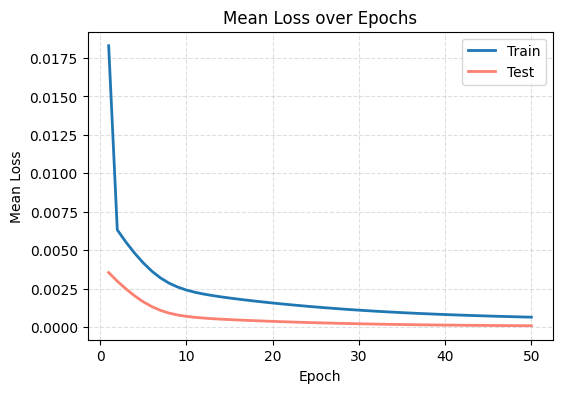


Train data - Mean PSNR: 37.071327

Sample image - PSNR: 25.076877


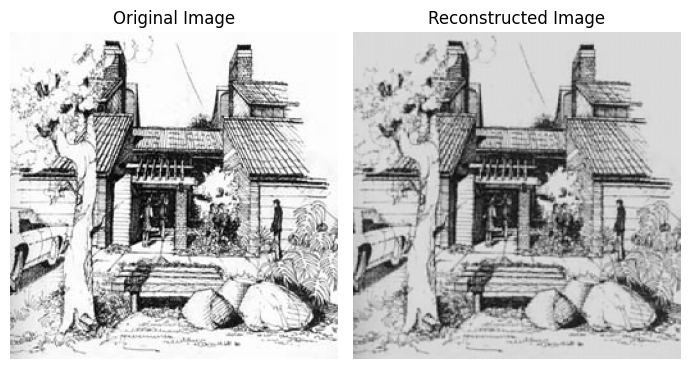


Test data - Mean PSNR: 41.736679

Sample image - PSNR: 43.225770


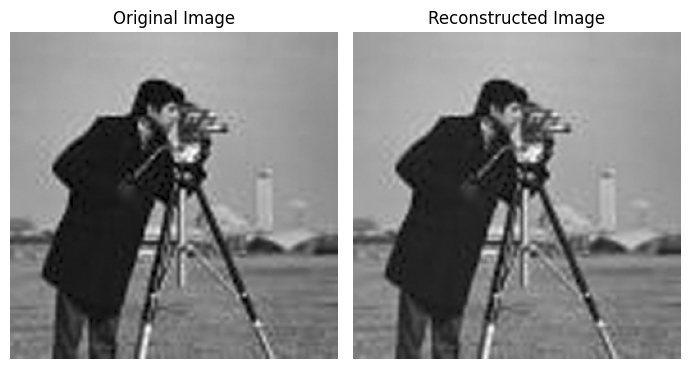

In [221]:
n4_psnr_train, n4_psnr_test = evaluate_model(n4_model, train_images, n4_train_images_reconstructed, test_images, n4_test_images_reconstructed)

### 8 * 8 Blocks

In [149]:
n = 8

n8_model = MLP(
    layer_sizes=[n*n, hidden_layer_size, n*n],
    activations=[Sigmoid(), Linear()],
    loss="mse",
    lr=lr,
    momentum=momentum,
    weight_type="xavier"
)

print(n8_model)

Multi-Layer Perceptron Details:
Input Size: 64
Output Size: 64
Architecture:
  Layer  1: Linear Block (64, 32),   Activation: Sigmoid
  Layer  2: Linear Block (32, 64),   Activation: Linear
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [150]:
n8_train_images_reconstructed, n8_test_images_reconstructed = train_model(n8_model, train_images, test_images, n, epochs, batch_size)

Convert image dataset to vectorized blocks:

91 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 93184.

5 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 5120.



Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.009953,   Test Loss: 0.005658
Epoch   10 /   50,   Train Loss: 0.006522,   Test Loss: 0.003169
Epoch   15 /   50,   Train Loss: 0.005411,   Test Loss: 0.002440
Epoch   20 /   50,   Train Loss: 0.004752,   Test Loss: 0.001987
Epoch   25 /   50,   Train Loss: 0.004226,   Test Loss: 0.001625
Epoch   30 /   50,   Train Loss: 0.003845,   Test Loss: 0.001370
Epoch   35 /   50,   Train Loss: 0.003579,   Test Loss: 0.001201
Epoch   40 /   50,   Train Loss: 0.003383,   Test Loss: 0.001084
Epoch   45 /   50,   Train Loss: 0.003224,   Test Loss: 0.000993
Epoch   50 /   50,   Train Loss: 0.003085,   Test Loss: 0.000917

Reconstruct full images from the model's output vectors:

93184 Vectors of size 64 converted to 93184 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.

5120 Vectors of size 64 converted to 5120 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.



Loss history over epochs:


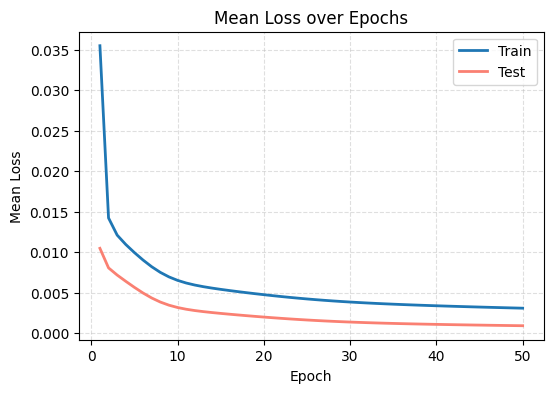


Train data - Mean PSNR: 28.482511

Sample image - PSNR: 18.595025


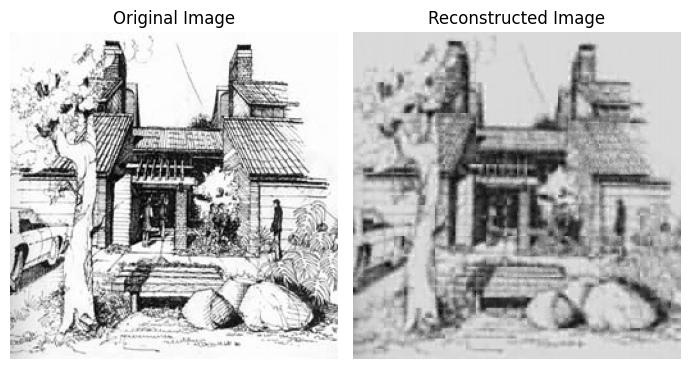


Test data - Mean PSNR: 31.664439

Sample image - PSNR: 33.001478


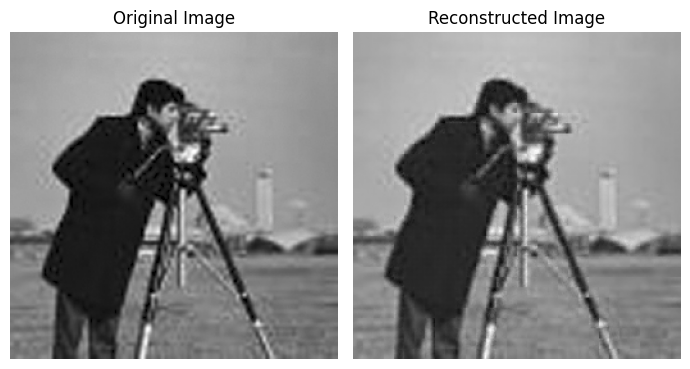

In [222]:
n8_psnr_train, n8_psnr_test = evaluate_model(n8_model, train_images, n8_train_images_reconstructed, test_images, n8_test_images_reconstructed)

### 16 * 16 Blocks

In [152]:
n = 16

n16_model = MLP(
    layer_sizes=[n*n, hidden_layer_size, n*n],
    activations=[Sigmoid(), Linear()],
    loss="mse",
    lr=lr,
    momentum=momentum,
    weight_type="xavier"
)

print(n16_model)

Multi-Layer Perceptron Details:
Input Size: 256
Output Size: 256
Architecture:
  Layer  1: Linear Block (256, 32),   Activation: Sigmoid
  Layer  2: Linear Block (32, 256),   Activation: Linear
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [153]:
n16_train_images_reconstructed, n16_test_images_reconstructed = train_model(n16_model, train_images, test_images, n, epochs, batch_size)

Convert image dataset to vectorized blocks:

91 Images of size 256*256 divided to 256 Blocks (shape 16*16) per image.
Each block transformed to a vector of size 256. Total Vectors: 23296.

5 Images of size 256*256 divided to 256 Blocks (shape 16*16) per image.
Each block transformed to a vector of size 256. Total Vectors: 1280.



Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.019858,   Test Loss: 0.013509
Epoch   10 /   50,   Train Loss: 0.014004,   Test Loss: 0.009168
Epoch   15 /   50,   Train Loss: 0.011675,   Test Loss: 0.007579
Epoch   20 /   50,   Train Loss: 0.010750,   Test Loss: 0.006862
Epoch   25 /   50,   Train Loss: 0.009940,   Test Loss: 0.006165
Epoch   30 /   50,   Train Loss: 0.009218,   Test Loss: 0.005529
Epoch   35 /   50,   Train Loss: 0.008627,   Test Loss: 0.005008
Epoch   40 /   50,   Train Loss: 0.008156,   Test Loss: 0.004600
Epoch   45 /   50,   Train Loss: 0.007776,   Test Loss: 0.004279
Epoch   50 /   50,   Train Loss: 0.007461,   Test Loss: 0.004017

Reconstruct full images from the model's output vectors:

23296 Vectors of size 256 converted to 23296 blocks of shape 16*16.
Every 256 blocks combined to restore an image of size 256*256.

1280 Vectors of size 256 converted to 1280 blocks of shape 16*16.
Every 256 blocks combined to restore an image of size 256*256.



Loss history over epochs:


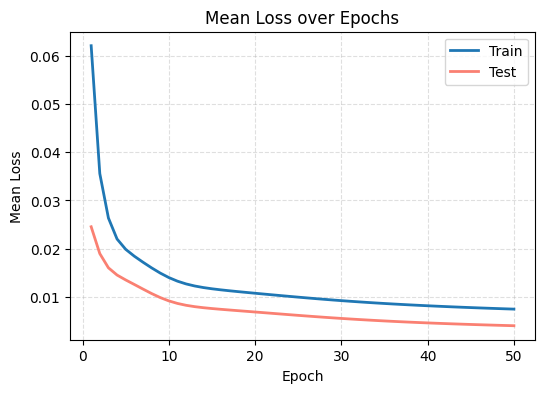


Train data - Mean PSNR: 23.305007

Sample image - PSNR: 15.992616


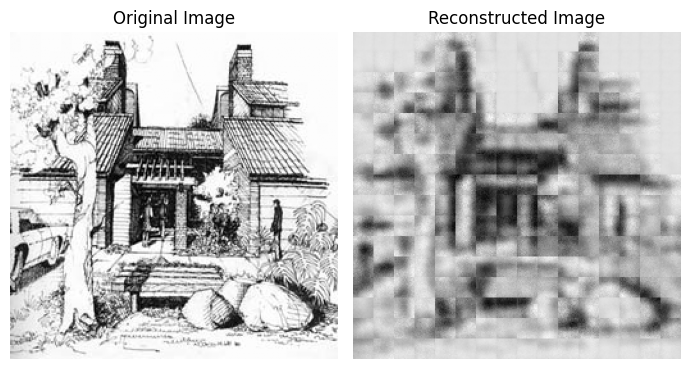


Test data - Mean PSNR: 24.995006

Sample image - PSNR: 25.684092


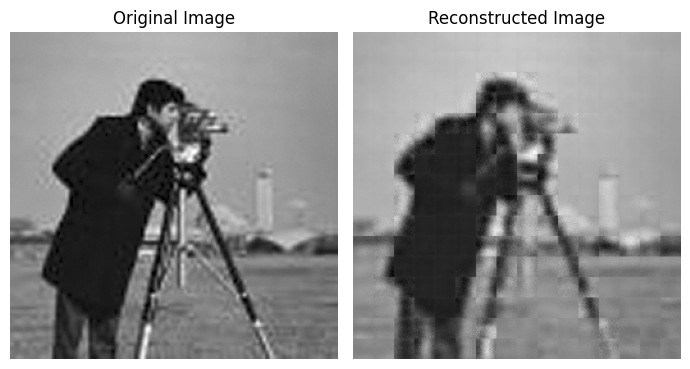

In [223]:
n16_psnr_train, n16_psnr_test = evaluate_model(n16_model, train_images, n16_train_images_reconstructed, test_images, n16_test_images_reconstructed)

### Block Size Comparison

In [275]:
print( 'Model Evaluation Summary:\n\n' +
       '         Model        | Train Loss | Test Loss  | Train PSNR  | Test PSNR\n' +
       '----------------------------------------------------------------------------\n' +
      f'  Block Size = 4      |  {n4_model.train_loss_list[-1]:6f}  |  {n4_model.test_loss_list[-1]:6f}  |  {n4_psnr_train:6f}  | {n4_psnr_test:6f}\n' +
      f'  Block Size = 8      |  {n8_model.train_loss_list[-1]:6f}  |  {n8_model.test_loss_list[-1]:6f}  |  {n8_psnr_train:6f}  | {n8_psnr_test:6f}\n' +
      f'  Block Size = 16     |  {n16_model.train_loss_list[-1]:6f}  |  {n16_model.test_loss_list[-1]:6f}  |  {n16_psnr_train:6f}  | {n16_psnr_test:6f}\n')

Model Evaluation Summary:

         Model        | Train Loss | Test Loss  | Train PSNR  | Test PSNR
----------------------------------------------------------------------------
  Block Size = 4      |  0.000642  |  0.000086  |  37.071327  | 41.736679
  Block Size = 8      |  0.003085  |  0.000917  |  28.482511  | 31.664439
  Block Size = 16     |  0.007461  |  0.004017  |  23.305007  | 24.995006



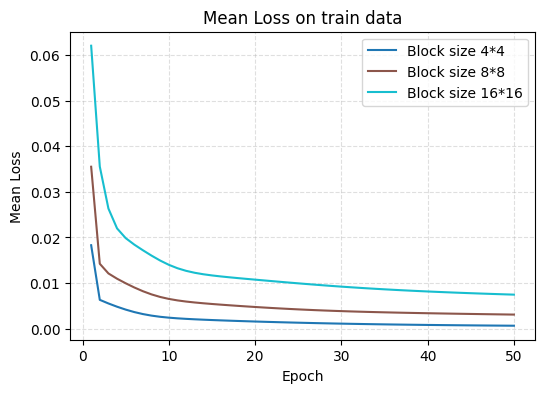

In [183]:
plot_train_metrics([n4_model.train_loss_list, n8_model.train_loss_list, n16_model.train_loss_list],
                    labels=['Block size 4*4', 'Block size 8*8', 'Block size 16*16'],
                    title="Mean Loss on train data",
                    figure_size=(6, 4))

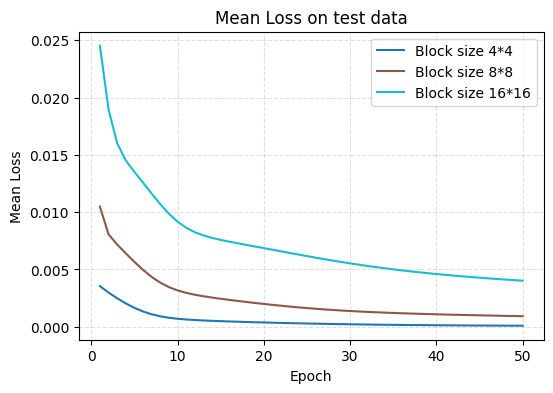

In [189]:
plot_train_metrics([n4_model.test_loss_list, n8_model.test_loss_list, n16_model.test_loss_list],
                    labels=['Block size 4*4', 'Block size 8*8', 'Block size 16*16'],
                    title="Mean Loss on test data",
                    figure_size=(6, 4))

## 2.3 Momentum

In [159]:
# default values for for all models in this section. Only the momentum value size changes
lr = 0.001
n = 8
hidden_layer_size = 16
epochs = 50
batch_size = 16

### Momentum 0.0

In [160]:
momentum = 0.0

m0_model = MLP(
    layer_sizes=[n*n, hidden_layer_size, n*n],
    activations=[Sigmoid(), Linear()],
    loss="mse",
    lr=lr,
    momentum=momentum,
    weight_type="xavier"
)

print(m0_model)

Multi-Layer Perceptron Details:
Input Size: 64
Output Size: 64
Architecture:
  Layer  1: Linear Block (64, 16),   Activation: Sigmoid
  Layer  2: Linear Block (16, 64),   Activation: Linear
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [161]:
m0_train_images_reconstructed, m0_test_images_reconstructed = train_model(m0_model, train_images, test_images, n, epochs, batch_size)

Convert image dataset to vectorized blocks:

91 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 93184.

5 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 5120.



Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.010676,   Test Loss: 0.006356
Epoch   10 /   50,   Train Loss: 0.007244,   Test Loss: 0.003751
Epoch   15 /   50,   Train Loss: 0.006090,   Test Loss: 0.002941
Epoch   20 /   50,   Train Loss: 0.005577,   Test Loss: 0.002579
Epoch   25 /   50,   Train Loss: 0.005111,   Test Loss: 0.002242
Epoch   30 /   50,   Train Loss: 0.004671,   Test Loss: 0.001926
Epoch   35 /   50,   Train Loss: 0.004296,   Test Loss: 0.001662
Epoch   40 /   50,   Train Loss: 0.004007,   Test Loss: 0.001461
Epoch   45 /   50,   Train Loss: 0.003795,   Test Loss: 0.001319
Epoch   50 /   50,   Train Loss: 0.003638,   Test Loss: 0.001219

Reconstruct full images from the model's output vectors:

93184 Vectors of size 64 converted to 93184 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.

5120 Vectors of size 64 converted to 5120 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.



Loss history over epochs:


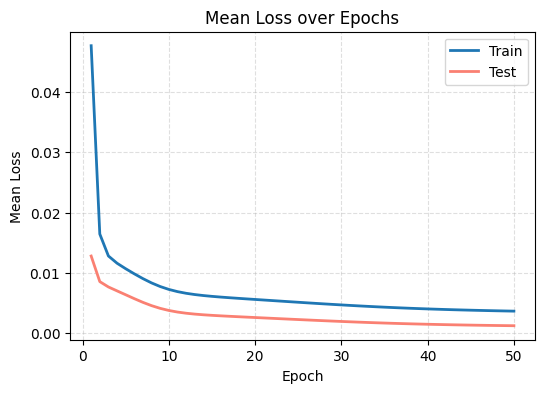


Train data - Mean PSNR: 27.502666

Sample image - PSNR: 18.076405


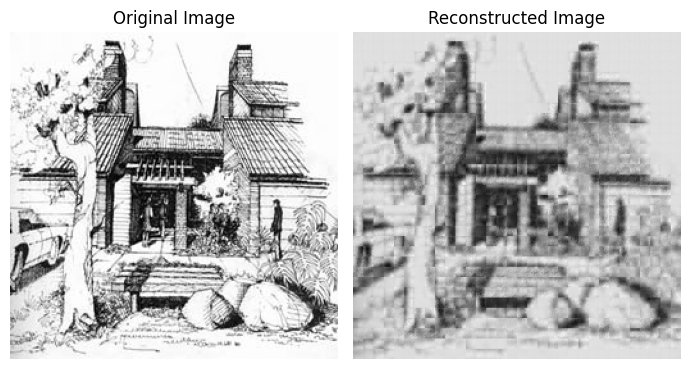


Test data - Mean PSNR: 30.412798

Sample image - PSNR: 31.606249


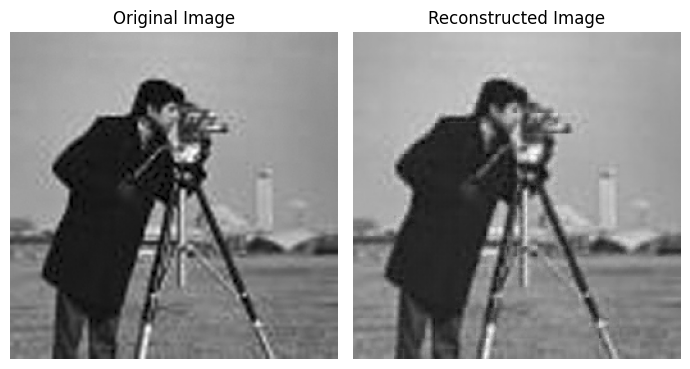

In [224]:
m0_psnr_train, m0_psnr_test = evaluate_model(m0_model, train_images, m0_train_images_reconstructed, test_images, m0_test_images_reconstructed)

### Momentum 0.5

In [241]:
momentum = 0.5

m05_model = MLP(
    layer_sizes=[n*n, hidden_layer_size, n*n],
    activations=[Sigmoid(), Linear()],
    loss="mse",
    lr=lr,
    momentum=momentum,
    weight_type="xavier"
)

print(m05_model)

Multi-Layer Perceptron Details:
Input Size: 64
Output Size: 64
Architecture:
  Layer  1: Linear Block (64, 32),   Activation: Sigmoid
  Layer  2: Linear Block (32, 64),   Activation: Linear
Learning Rate: 0.001
Momentum: 0.5
Weight Initialization Type: xavier


In [242]:
m05_train_images_reconstructed, m05_test_images_reconstructed = train_model(m05_model, train_images, test_images, n, epochs, batch_size)

Convert image dataset to vectorized blocks:

91 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 93184.

5 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 5120.



Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.011502,   Test Loss: 0.006875
Epoch   10 /   50,   Train Loss: 0.008329,   Test Loss: 0.004510
Epoch   15 /   50,   Train Loss: 0.006454,   Test Loss: 0.003149
Epoch   20 /   50,   Train Loss: 0.005645,   Test Loss: 0.002604
Epoch   25 /   50,   Train Loss: 0.005146,   Test Loss: 0.002266
Epoch   30 /   50,   Train Loss: 0.004725,   Test Loss: 0.001975
Epoch   35 /   50,   Train Loss: 0.004361,   Test Loss: 0.001724
Epoch   40 /   50,   Train Loss: 0.004063,   Test Loss: 0.001520
Epoch   45 /   50,   Train Loss: 0.003828,   Test Loss: 0.001363
Epoch   50 /   50,   Train Loss: 0.003644,   Test Loss: 0.001244

Reconstruct full images from the model's output vectors:

93184 Vectors of size 64 converted to 93184 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.

5120 Vectors of size 64 converted to 5120 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.



Loss history over epochs:


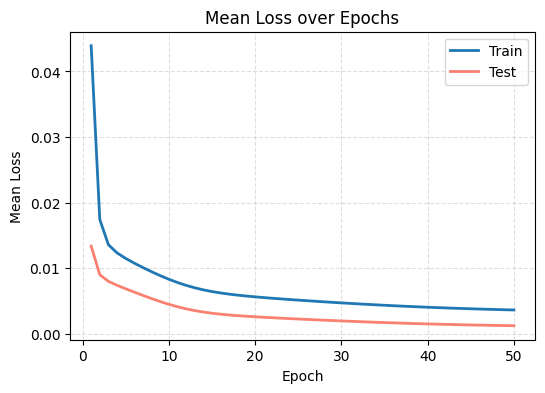


Train data - Mean PSNR: 27.382973

Sample image - PSNR: 18.052882


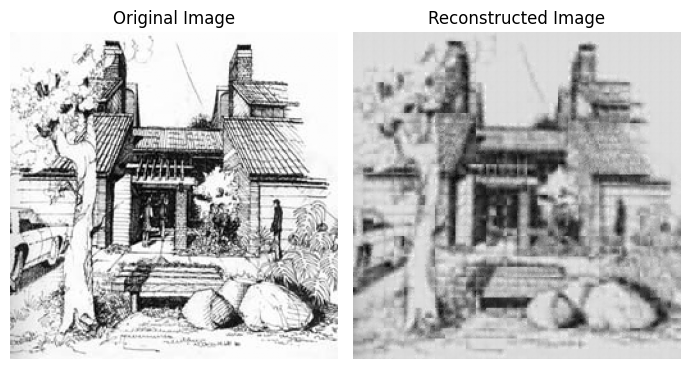


Test data - Mean PSNR: 30.267065

Sample image - PSNR: 31.483693


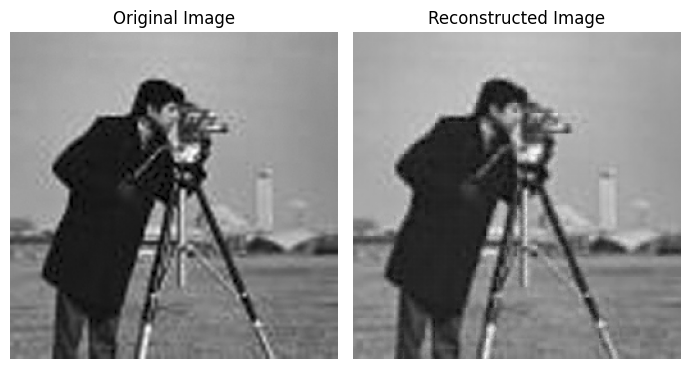

In [279]:
m05_psnr_train, m05_psnr_test = evaluate_model(m05_model, train_images, m05_train_images_reconstructed, test_images, m05_test_images_reconstructed)

### Momentum Comparison

In [280]:
print( 'Model Evaluation Summary:\n\n' +
       '         Model        | Train Loss | Test Loss  | Train PSNR  |  Test PSNR  |  Convergence Time\n' +
       '-------------------------------------------------------------------------------------------------\n' +
      f'    Momentum = 0.0    |  {m0_model.train_loss_list[-1]:6f}  |  {m0_model.test_loss_list[-1]:6f}  |  {m0_psnr_train:6f}  |  {m0_psnr_test:6f}  |     10 Epochs\n' +
      f'    Momentum = 0.5    |  {m05_model.train_loss_list[-1]:6f}  |  {m05_model.test_loss_list[-1]:6f}  |  {m05_psnr_train:6f}  |  {m05_psnr_test:6f}  |     15 Epochs\n')

Model Evaluation Summary:

         Model        | Train Loss | Test Loss  | Train PSNR  |  Test PSNR  |  Convergence Time
-------------------------------------------------------------------------------------------------
    Momentum = 0.0    |  0.003638  |  0.001219  |  27.502666  |  30.412798  |     10 Epochs
    Momentum = 0.5    |  0.003644  |  0.001244  |  27.382973  |  30.267065  |     15 Epochs



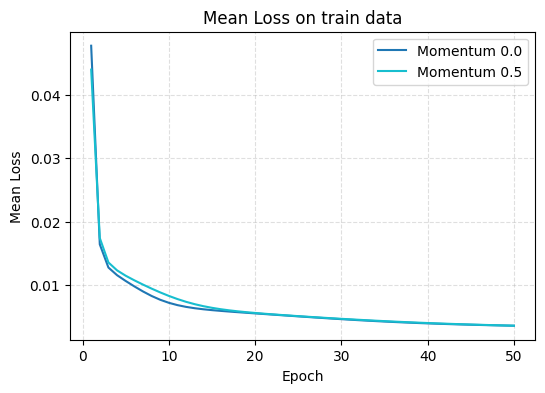

In [244]:
plot_train_metrics([m0_model.train_loss_list, m05_model.train_loss_list],
                    labels=['Momentum 0.0', 'Momentum 0.5'],
                    title="Mean Loss on train data",
                    figure_size=(6, 4))

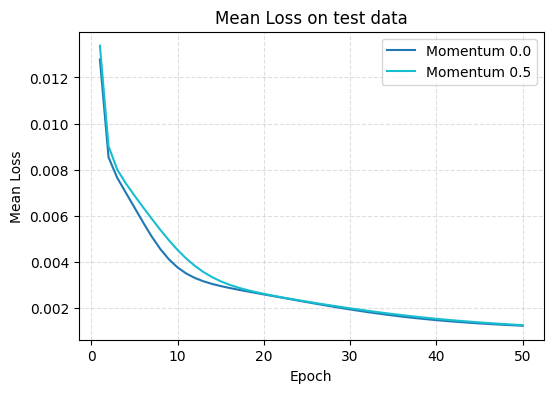

In [245]:
plot_train_metrics([m0_model.test_loss_list, m05_model.test_loss_list],
                    labels=['Momentum 0.0', 'Momentum 0.5'],
                    title="Mean Loss on test data",
                    figure_size=(6, 4))